# Potencial de optimización por umbrales — zoom ciudad → barrio
### Sprint 3 — Marketing i Estratègia Comercial · v6 (15/07/2026)

*¿Qué ciudades y barrios presentan mayor potencial de optimización
considerando las reseñas, la puntuación de la zona y la disponibilidad
mínima/máxima de noches?*

## 1. Introducción: cómo vamos a proceder

Fijamos un **umbral por cada una de las 4 variables** de la pregunta y
comprobamos si hay **potencial de optimización** (está fuera del rango
deseable). El análisis se hace como un **zoom en dos niveles**:

1. **Nivel 1 — Ciudades (visión global):** qué ciudades fallan qué
   umbral y dónde se concentra el volumen. Hallazgos generales. Se
   analizan **todas** las ciudades, sin filtro de tamaño.
2. **Nivel 2 — Barrios (zoom):** bajamos al detalle, vemos qué barrios
   concretos tienen más potencial y qué acción toca. Hallazgos finos.
3. **Piloto** en las 2 ciudades con mayor **volumen** de oportunidad.

Las 4 variables son **palancas accionables**, aunque de naturaleza
distinta: **rating y noches** se mejoran de forma directa sobre el
anuncio (⚠️ si hay algo que hacer); **ubicación** se mejora de forma
indirecta, con **campañas de marketing** que den valor y visibilidad al
barrio. El criterio de accionabilidad de la ubicación es **únicamente**
el punto de corte `review_scores_location < 4,8` (reescalado a 0-5):
todo anuncio por debajo suma potencial de optimización al barrio; no se
descarta ningún barrio por tener ubicación floja, se trata como una
acción más.

El filtro **N ≥ 20** anuncios es algo **distinto e independiente**: no
mide accionabilidad, solo garantiza que el barrio tiene muestra
suficiente para que la mediana y los % sean fiables. Se aplica **solo
al bajar a nivel barrio** (Nivel 2), **después** de haber analizado ya
las ciudades completas (Nivel 1, sin ese filtro).

### 1.1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize, to_rgba

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### 1.2. Carga del dataset

Usamos el **clean_dataset del 13_07** (versión actualizada, 9.507 filas).

> **_Aviso:_** esta versión trae los acentos corruptos por un problema
> de codificación (`el Barri G�tic`); el símbolo `�` sustituye siempre a
> una vocal acentuada (o `ñ`/`ç`). Lo corregimos justo debajo, **solo en
> el `data` de este notebook** (no se toca el CSV), reponiendo la letra
> con la tilde/diacrítico que corresponde según el idioma del barrio
> (català en Barcelona, Girona, Mallorca y Menorca; castellano en
> Madrid y Sevilla).

In [2]:
RUTA = "../Data/clean_dataset_13_07_2026.csv"
df = pd.read_csv(RUTA)

cols = [
    "apartment_id", "neighbourhood_name", "city",
    "review_scores_rating", "review_scores_location",
    "minimum_nights", "maximum_nights",
]
data = df[cols].copy()
print("filas:", len(data))
data.head()

filas: 9650


,apartment_id,neighbourhood_name,city,review_scores_rating,review_scores_location,minimum_nights,maximum_nights
0,11411444,la Vila de Gr�cia,Barcelona,83.0,9.0,3,1125
1,11002274,el Raval,Barcelona,87.0,10.0,3,1125
2,15254167,Hostafrancs,Barcelona,80.0,10.0,1,1125
3,16272738,el Baix Guinard�,Barcelona,100.0,8.0,2,1125
4,1198074,la Dreta de l'Eixample,Barcelona,95.0,10.0,1,1125


## 2. Los 4 umbrales (uno por variable de la pregunta)

| Variable | Columna | Hay potencial / acción si… | Fuente |
|---|---|---|---|
| Reseñas (calidad) | `review_scores_rating` | **≤ 4,8** (por debajo del estándar) | Superhost |
| Puntuación de zona | `review_scores_location` | **< 4,8** (potencial de marketing de zona) | subcategoría Superhost |
| Noches mínimas | `minimum_nights` | **fuera de 3-4** | óptimo de ingresos |
| Noches máximas | `maximum_nights` | **> 31** | régimen turístico legal |

- **Rating ≤ 4,8 = potencial.** Estándar Superhost (+22% reservas); como
  es palanca, nos interesa **lo que está por debajo** (recorrido de mejora).
- **Location < 4,8 = potencial de marketing.** No hay umbral académico
  absoluto; anclamos al 4,8 (subcategoría Superhost). La ubicación
  física es fija, pero su atractivo percibido sí se puede reforzar con
  **marketing de zona** (contenido, alianzas locales, promoción de
  puntos de interés).
- **Noches mín fuera de 3-4 = potencial.** Óptimo de ingresos 3-4 noches
  (+35-41% vs 1). Por debajo: rotación/limpieza; por encima: barreras.
- **Noches máx > 31 = acción legal.** Límite turístico catalán (Decreto
  159/2012) → regularización.

> **_A confirmar:_** banda de noches mín **[3,4] fija** vs desviación de
> la mediana de ciudad; y `max_nights` > 31 casi universal por el
> **default de plataforma** (1125) → regularización transversal.

**Fuentes:** AirDNA, Airbnb Help 1257, MDPI 2025, shorttermrentalz,
Decreto 159/2012.

## 3. Limpieza, escalado y banderas

Corrección de acentos corruptos en 'neighbourhood_name' (solo en `data`,
no se toca el CSV). El carácter '�' sustituye siempre a una vocal con
tilde (o ñ/ç); reponemos la grafía correcta según el idioma del barrio: català en Barcelona/Girona/Mallorca/Menorca, castellano en Madrid/Sevilla.


In [3]:
NEIGHBOURHOOD_FIX = {
    # Barcelona (català)
    "Can Bar�": "Can Baró",
    "Diagonal Mar i el Front Mar�tim del Poblenou": "Diagonal Mar i el Front Marítim del Poblenou",
    "Proven�als del Poblenou": "Provençals del Poblenou",
    "Sant Gen�s dels Agudells": "Sant Genís dels Agudells",
    "Sant Mart� de Proven�als": "Sant Martí de Provençals",
    "Sarri�": "Sarrià",
    "Torre Bar�": "Torre Baró",
    "el Baix Guinard�": "el Baix Guinardó",
    "el Barri G�tic": "el Barri Gòtic",
    "el Bes�s i el Maresme": "el Besòs i el Maresme",
    "el Camp d'en Grassot i Gr�cia Nova": "el Camp d'en Grassot i Gràcia Nova",
    "el Congr�s i els Indians": "el Congrés i els Indians",
    "el Guinard�": "el Guinardó",
    "el Putxet i el Farr�": "el Putxet i el Farró",
    "el Tur� de la Peira": "el Turó de la Peira",
    "la Sagrada Fam�lia": "la Sagrada Família",
    "la Vila Ol�mpica del Poblenou": "la Vila Olímpica del Poblenou",
    "la Vila de Gr�cia": "la Vila de Gràcia",
    # Girona (català)
    "Arb�cies": "Arbúcies",
    "Bellcaire d'Empord�": "Bellcaire d'Empordà",
    "Besal�": "Besalú",
    "Bescan�": "Bescanó",
    "B�scara": "Bàscara",
    "Cadaqu�s": "Cadaqués",
    "Campdev�nol": "Campdevànol",
    "Castell� d'Emp�ries": "Castelló d'Empúries",
    "Celr�": "Celrà",
    "Cornell� del Terri": "Cornellà del Terri",
    "Cru�lles, Monells i Sant Sadurn� de l'Heura": "Cruïlles, Monells i Sant Sadurní de l'Heura",
    "Foix�": "Foixà",
    "Is�vol": "Isòvol",
    "La Tallada d'Empord�": "La Tallada d'Empordà",
    "Llad�": "Lladó",
    "Llan��": "Llançà",
    "Ll�via": "Llívia",
    "Mai� de Montcal": "Maià de Montcal",
    "Ma�anet de la Selva": "Maçanet de la Selva",
    "Palam�s": "Palamós",
    "Palau de Santa Eul�lia": "Palau de Santa Eulàlia",
    "Parlav�": "Parlavà",
    "Pont�s": "Pontós",
    "Puigcerd�": "Puigcerdà",
    "Rab�s": "Rabós",
    "Regenc�s": "Regencós",
    "Rupi�": "Rupià",
    "Sant Feliu de Gu�xols": "Sant Feliu de Guíxols",
    "Sant Juli� de Ramis": "Sant Julià de Ramis",
    "Sant Lloren� de la Muga": "Sant Llorenç de la Muga",
    "Sant Mart� Vell": "Sant Martí Vell",
    "Sant Mart� de Ll�mena": "Sant Martí de Llémena",
    "Sant Miquel de Fluvi�": "Sant Miquel de Fluvià",
    "Sant Pau de Seg�ries": "Sant Pau de Segúries",
    "Seriny�": "Serinyà",
    "Torroella de Fluvi�": "Torroella de Fluvià",
    "Torroella de Montgr�": "Torroella de Montgrí",
    "Tortell�": "Tortellà",
    "Ull�": "Ullà",
    "Ur�s": "Urús",
    "Vallfogona de Ripoll�s": "Vallfogona de Ripollès",
    "Ventall�": "Ventalló",
    "Vidr�": "Vidrà",
    "Vilaju�ga": "Vilajuïga",
    "Vila�r": "Vilaür",
    # Madrid (castellano)
    "Arg�elles": "Argüelles",
    "Casco Hist�rico de Barajas": "Casco Histórico de Barajas",
    "Casco Hist�rico de Vallecas": "Casco Histórico de Vallecas",
    "Casco Hist�rico de Vic�lvaro": "Casco Histórico de Vicálvaro",
    "Ciudad Jard�n": "Ciudad Jardín",
    "Concepci�n": "Concepción",
    "C�rmenes": "Cármenes",
    "El Plant�o": "El Plantío",
    "Entrev�as": "Entrevías",
    "Fontarr�n": "Fontarrón",
    "Hell�n": "Hellín",
    "Hispanoam�rica": "Hispanoamérica",
    "Jer�nimos": "Jerónimos",
    "Moscard�": "Moscardó",
    "Ni�o Jes�s": "Niño Jesús",
    "Nueva Espa�a": "Nueva España",
    "Opa�el": "Opañel",
    "Pac�fico": "Pacífico",
    "Pe�agrande": "Peñagrande",
    "San Andr�s": "San Andrés",
    "San Ferm�n": "San Fermín",
    "Tim�n": "Timón",
    "Zof�o": "Zofío",
    # Mallorca (català balear)
    "Alar�": "Alaró",
    "Alc�dia": "Alcúdia",
    "Art�": "Artà",
    "B�ger": "Búger",
    "Calvi�": "Calvià",
    "Dey�": "Deià",
    "Llub�": "Llubí",
    "Marratx�": "Marratxí",
    "Montu�ri": "Montuïri",
    "Pollen�a": "Pollença",
    "Sant Lloren� des Cardassar": "Sant Llorenç des Cardassar",
    "Santa Eug�nia": "Santa Eugènia",
    "Santa Mar�a del Cam�": "Santa Maria del Camí",
    "Santany�": "Santanyí",
    "S�ller": "Sóller",
    # Menorca (català / castellanitzat)
    "Mah�n": "Mahón",
    "Sant Llu�s": "Sant Lluís",
    # Sevilla (castellano)
    "Barrio Le�n": "Barrio León",
    "Carretera de Carmona, Mar�a Auxiliadora, Fontanal": "Carretera de Carmona, María Auxiliadora, Fontanal",
    "Doctor Barraquer, G. Renfe, Policl�nico": "Doctor Barraquer, G. Renfe, Policlínico",
    "El Roc�o": "El Rocío",
    "El Tard�n, El Carmen": "El Tardón, El Carmen",
    "Encarnaci�n, Regina": "Encarnación, Regina",
    "Heli�polis": "Heliópolis",
    "La Palmilla, Doctor Mara��n": "La Palmilla, Doctor Marañón",
    "Le�n XIII, Los Naranjos": "León XIII, Los Naranjos",
    "Nervi�n": "Nervión",
    "Prado, Parque Mar�a Luisa": "Prado, Parque María Luisa",
    "San Bartolom�": "San Bartolomé",
    "San Jos� Obrero": "San José Obrero",
    "San Juli�n": "San Julián",
    "Tiro de L�nea, Santa Genoveva": "Tiro de Línea, Santa Genoveva",
}

n_antes = data["neighbourhood_name"].astype(str).str.contains("�").sum()
data["neighbourhood_name"] = data["neighbourhood_name"].replace(NEIGHBOURHOOD_FIX)
n_despues = data["neighbourhood_name"].astype(str).str.contains("�").sum()
print("barrios con '�' antes:", n_antes, "| después:", n_despues)

barrios con '�' antes: 2110 | después: 0


El `rating` viene en **0-100** y la `location` en **0-10**; los pasamos
a **0-5** para compararlos con el 4,8.

In [4]:
data = data.dropna(
    subset=["review_scores_rating", "review_scores_location"]
)
data["rating_0_5"] = data["review_scores_rating"] / 20
data["location_0_5"] = data["review_scores_location"] / 2
print("filas tras limpiar:", len(data))

filas tras limpiar: 7010


In [5]:
U_RATING = 4.8       # estándar Superhost
U_LOCATION = 4.8     # umbral de referencia (subcategoría Superhost)
U_MIN_LO = 3         # banda óptima de noches mínimas
U_MIN_HI = 4
U_MAX = 31           # límite legal turístico
N_MIN = 20           # muestra mínima por barrio

data["acc_ubicacion"] = data["location_0_5"] < U_LOCATION
data["acc_rating"] = data["rating_0_5"] <= U_RATING
data["acc_min"] = ~data["minimum_nights"].between(
    U_MIN_LO, U_MIN_HI
)
data["acc_max"] = data["maximum_nights"] > U_MAX

**Funciones de apoyo** (evaluación, veredictos, semáforo, acciones).

In [6]:
def evaluar(gdf, claves):
    g = gdf.groupby(claves)
    t = g.agg(
        n=("apartment_id", "size"),
        rating_med=("rating_0_5", "median"),
        location_med=("location_0_5", "median"),
        min_med=("minimum_nights", "median"),
        max_med=("maximum_nights", "median"),
        pct_ubic_debil=("acc_ubicacion", "mean"),
        pct_rating_bajo=("acc_rating", "mean"),
        pct_min_fuera=("acc_min", "mean"),
        pct_max_alto=("acc_max", "mean"),
    ).reset_index()
    return t


def veredictos(t):
    t = t.copy()
    t["a_ubicacion"] = t["location_med"] < U_LOCATION
    t["a_rating"] = t["rating_med"] <= U_RATING
    t["a_min"] = ~t["min_med"].between(U_MIN_LO, U_MIN_HI)
    t["a_max"] = t["max_med"] > U_MAX
    t["n_acciones"] = t[
        ["a_ubicacion", "a_rating", "a_min", "a_max"]
    ].sum(axis=1)
    return t


def semaforo(t, id_cols):
    s = t.copy()
    for c in ["a_ubicacion", "a_rating", "a_min", "a_max"]:
        s[c] = s[c].map({True: "⚠️", False: "✅"})
    cols = id_cols + ["n", "a_ubicacion", "a_rating",
                      "a_min", "a_max", "n_acciones"]
    return s[cols].sort_values("n_acciones", ascending=False)


def acciones(r):
    a = []
    if r["a_ubicacion"]:
        a.append("ubicación floja: campaña de marketing de zona")
    if r["a_rating"]:
        a.append("calidad: subir rating hacia 4,8+")
    if r["a_min"]:
        d = "subir" if r["min_med"] < U_MIN_LO else "bajar"
        a.append("noches mín: %s a 3-4" % d)
    if r["a_max"]:
        a.append("noches máx: regularizar >31")
    return " | ".join(a) if a else "sin acciones"

Construimos ya las dos tablas (ciudad y barrio) y el **índice de
accionabilidad** por barrio (media de los 3 % de potencial, 0-100).

In [7]:
ciudad = veredictos(evaluar(data, ["city"]))
ciudad["acciones"] = ciudad.apply(acciones, axis=1)

barrio = evaluar(data, ["city", "neighbourhood_name"])
barrio = veredictos(barrio[barrio["n"] >= N_MIN])
barrio["acciones"] = barrio.apply(acciones, axis=1)
barrio["score_accion"] = 100 * (
    barrio["pct_ubic_debil"]
    + barrio["pct_rating_bajo"]
    + barrio["pct_min_fuera"]
    + barrio["pct_max_alto"]
) / 4
foco = barrio.copy()  # ya no se descarta ningún barrio por ubicación:
                       # la ubicación floja también es accionable (marketing)
print("barrios N>=20:", len(barrio))

barrios N>=20: 82


## 4. NIVEL 1 · Visión global por ciudad

Primero miramos el bosque: qué ciudades fallan qué umbral y dónde está
el volumen. `⚠️` = potencial/acción (incluida la ubicación, vía
marketing de zona) · `✅` = sin acción necesaria.

In [8]:
semaforo(ciudad, ["city"])

,city,n,a_ubicacion,a_rating,a_min,a_max,n_acciones
0,Barcelona,2079,✅,⚠️,⚠️,⚠️,3
1,Girona,902,✅,⚠️,⚠️,⚠️,3
2,Madrid,1644,✅,⚠️,⚠️,⚠️,3
4,Menorca,144,✅,⚠️,⚠️,⚠️,3
5,Málaga,415,✅,⚠️,⚠️,⚠️,3
6,Sevilla,427,✅,⚠️,⚠️,⚠️,3
7,Valencia,428,✅,⚠️,⚠️,⚠️,3
3,Mallorca,971,✅,⚠️,✅,⚠️,2


### 4.1. % de anuncios afectados por ciudad

In [9]:
vis = ciudad[["city", "n", "pct_ubic_debil", "pct_rating_bajo",
              "pct_min_fuera", "pct_max_alto"]].copy()
for c in ["pct_ubic_debil", "pct_rating_bajo",
          "pct_min_fuera", "pct_max_alto"]:
    vis[c] = (vis[c] * 100).round(1)
vis.sort_values("pct_rating_bajo", ascending=False)

,city,n,pct_ubic_debil,pct_rating_bajo,pct_min_fuera,pct_max_alto
0,Barcelona,2079,35.6,71.9,71.8,75.9
7,Valencia,428,36.2,67.3,78.7,76.2
5,Málaga,415,41.0,66.5,80.7,85.3
1,Girona,902,38.2,62.6,81.5,74.3
2,Madrid,1644,27.3,61.9,79.1,79.7
6,Sevilla,427,25.5,60.7,86.7,80.3
4,Menorca,144,38.9,57.6,76.4,79.9
3,Mallorca,971,40.0,51.0,72.9,84.8


### 4.2. Dónde está el volumen de oportunidad

Priorizamos por **escala**: nº de **anuncios accionables** ≈
Σ (anuncios del barrio × su accionabilidad), sobre todos los barrios
evaluados (N≥20). Así premiamos las ciudades con **más barrios y
anuncios sobre los que actuar**, no solo la severidad.

In [10]:
foco["accionables"] = foco["n"] * foco["score_accion"] / 100
oportunidad = foco.groupby("city").agg(
    barrios=("n", "size"),
    anuncios=("n", "sum"),
    score_medio=("score_accion", "mean"),
    accionables=("accionables", "sum"),
).sort_values("accionables", ascending=False)
oportunidad.round(1)

,barrios,anuncios,score_medio,accionables
city,,,,
Barcelona,22,1739,65.2,1086.2
Madrid,13,1032,60.4,621.2
Girona,16,694,64.0,447.8
Mallorca,13,704,62.8,443.8
Málaga,4,384,69.6,260.5
Sevilla,7,226,58.7,132.8
Valencia,4,129,63.5,81.8
Menorca,3,110,58.0,66.8


> **_Aviso — cobertura del filtro N≥20:_** el zoom por barrio (Nivel 2)
> solo ve una parte de cada ciudad; los barrios con menos de 20 anuncios
> quedan fuera del detalle fino. La cobertura varía mucho por ciudad —
> en Valencia y Sevilla el barrio-level se apoya en menos de la mitad de
> sus anuncios reales, así que sus conclusiones a nivel barrio son menos
> representativas que las de Barcelona o Málaga:

In [11]:
cobertura = ciudad.set_index("city")[["n"]].rename(
    columns={"n": "anuncios_ciudad"}
)
cobertura["anuncios_en_barrios_N20"] = barrio.groupby("city")["n"].sum()
cobertura["pct_excluido"] = (
    100 * (cobertura["anuncios_ciudad"] - cobertura["anuncios_en_barrios_N20"])
    / cobertura["anuncios_ciudad"]
).round(1)
cobertura.sort_values("pct_excluido", ascending=False)

,anuncios_ciudad,anuncios_en_barrios_N20,pct_excluido
city,,,
Valencia,428,129,69.9
Sevilla,427,226,47.1
Madrid,1644,1032,37.2
Mallorca,971,704,27.5
Menorca,144,110,23.6
Girona,902,694,23.1
Barcelona,2079,1739,16.4
Málaga,415,384,7.5


### 4.3. Índice de accionabilidad por ciudad

Índice 0-100% que tiene en cuenta el **volumen de alojamientos**, no solo
el % de potencial en bruto: partimos de `accionables` (Σ n ×
score_accion / 100, tabla 4.2, sobre barrios N≥20) e indexamos a la
ciudad con más volumen = 100%. Así evitamos que una ciudad con pocos
alojamientos (p. ej. Málaga, Valencia) salga arriba solo por un % más
alto calculado sobre una muestra pequeña.

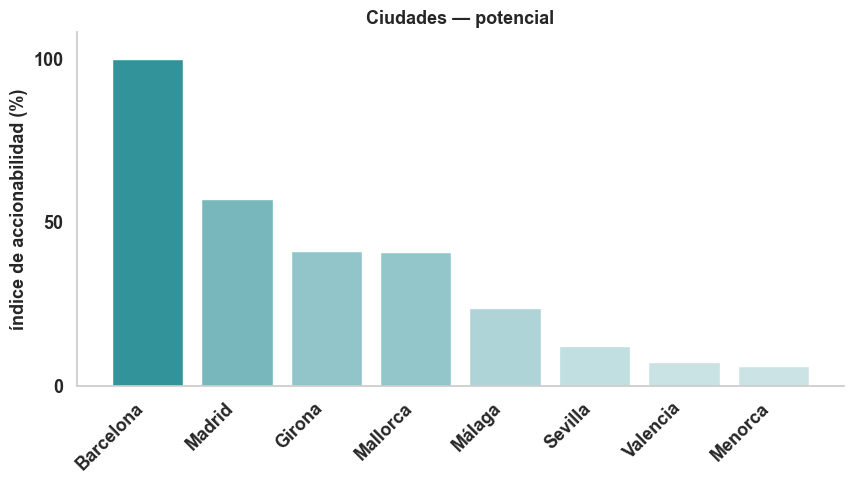

In [12]:
# Color de marca (placeholder: ajustar al logo real).
STAY_COLOR = "#32939b"
ALPHA_MIN, ALPHA_MAX = 0.25, 1.0  # menos ranking -> más transparente
FONTSIZE = 13

vol = oportunidad["accionables"].sort_values(ascending=False)
indice = 100 * vol / vol.max()  # ciudad con más volumen = 100%

norm_ciudad = Normalize(indice.min(), indice.max())
alphas = ALPHA_MIN + norm_ciudad(indice) * (ALPHA_MAX - ALPHA_MIN)
colors = [to_rgba(STAY_COLOR, alpha=a) for a in alphas]

fig, ax = plt.subplots(figsize=(0.9 * len(indice) + 1.5, 5))
ax.bar(indice.index, indice.values, color=colors)
ax.set_title("Ciudades — potencial", fontsize=FONTSIZE, fontweight="bold")
ax.set_ylabel("índice de accionabilidad (%)",
              fontsize=FONTSIZE, fontweight="bold")
ax.set_ylim(0, 108)
ax.set_yticks([0, 50, 100])
ax.tick_params(axis="y", labelsize=FONTSIZE)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         fontsize=FONTSIZE, fontweight="bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")
ax.grid(False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

### 4.4. Hallazgos a nivel ciudad

In [13]:
resumen = pd.DataFrame({
    "ubicacion_floja (accion)": [int(ciudad["a_ubicacion"].sum())],
    "rating<=4,8 (accion)": [int(ciudad["a_rating"].sum())],
    "noches_min_fuera": [int(ciudad["a_min"].sum())],
    "noches_max>31": [int(ciudad["a_max"].sum())],
}, index=["nº de ciudades (de 8)"])
resumen

,ubicacion_floja (accion),"rating<=4,8 (accion)",noches_min_fuera,noches_max>31
nº de ciudades (de 8),0,8,7,8


Lo que aparece al mirar las 8 ciudades:

- **Ubicación: accionable, pero vía marketing.** A nivel ciudad las 8
  tienen mediana ≥4,8 (no hay acción de ubicación que lanzar en bloque),
  pero a nivel barrio sí aparecen zonas con ubicación floja (ver 5.4):
  para esas, la palanca es **marketing de zona**, no descartarlas del
  foco.
- **Rating: la palanca más generalizada.** Las **8 de 8** ciudades
  tienen la mediana **por debajo de 4,8** (ninguna cumple el estándar
  Superhost), con un **51-72%** de anuncios por debajo → recorrido de
  calidad claro, sistemático y no puntual.
- **Noches mínimas por debajo del óptimo en 7 de 8 ciudades.** Solo
  Mallorca queda dentro de la banda 3-4 → acción típica **subir** la
  estancia mínima en el resto.
- **Noches máximas: incumplimiento universal (8 de 8)** por el default
  de plataforma (1125) → **regularización transversal**, no discrimina
  zonas.
- **El volumen se concentra en Barcelona y Madrid** (tabla 4.2): son las
  ciudades con más barrios y anuncios accionables → foco del piloto
  (aunque, ver aviso arriba, en Madrid esa lectura de barrio se apoya en
  solo el 63% de sus anuncios).

## 5. NIVEL 2 · Zoom por barrio

Ahora bajamos al detalle dentro de cada ciudad.

### 5.1. Semáforo de barrios (N ≥ 20)

In [14]:
print("barrios evaluados:", len(barrio))
semaforo(barrio, ["city", "neighbourhood_name"]).head(15)

barrios evaluados: 82


,city,neighbourhood_name,n,a_ubicacion,a_rating,a_min,a_max,n_acciones
231,Madrid,Guindalera,23,⚠️,⚠️,⚠️,⚠️,4
39,Barcelona,el Parc i la Llacuna del Poblenou,36,⚠️,⚠️,⚠️,⚠️,4
276,Madrid,San Diego,23,⚠️,⚠️,⚠️,⚠️,4
55,Barcelona,la Nova Esquerra de l'Eixample,96,⚠️,⚠️,⚠️,⚠️,4
354,Málaga,Carretera de Cadiz,46,⚠️,⚠️,⚠️,⚠️,4
358,Málaga,Cruz De Humilladero,24,⚠️,⚠️,⚠️,⚠️,4
42,Barcelona,el Putxet i el Farró,24,⚠️,⚠️,⚠️,⚠️,4
359,Málaga,Este,46,⚠️,⚠️,⚠️,⚠️,4
54,Barcelona,la Maternitat i Sant Ramon,23,⚠️,⚠️,⚠️,⚠️,4
29,Barcelona,el Besòs i el Maresme,26,⚠️,⚠️,⚠️,⚠️,4


### 5.2. Accionabilidad por barrio en cada ciudad

> **_Aviso:_** el dataset **no trae coordenadas**, así que **no es un
> mapa geográfico**. Por cada ciudad, los **10 barrios de mayor
> potencial** (de entre los evaluados, N≥20), ordenados y coloreados en
> el **verde de StaySpain**, con **más opacidad = más accionable** y más
> transparencia cuanto menor es el ranking de accionabilidad.

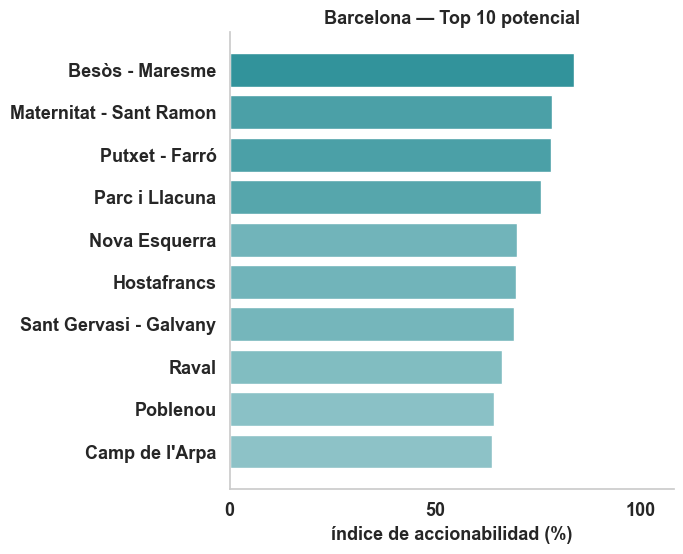

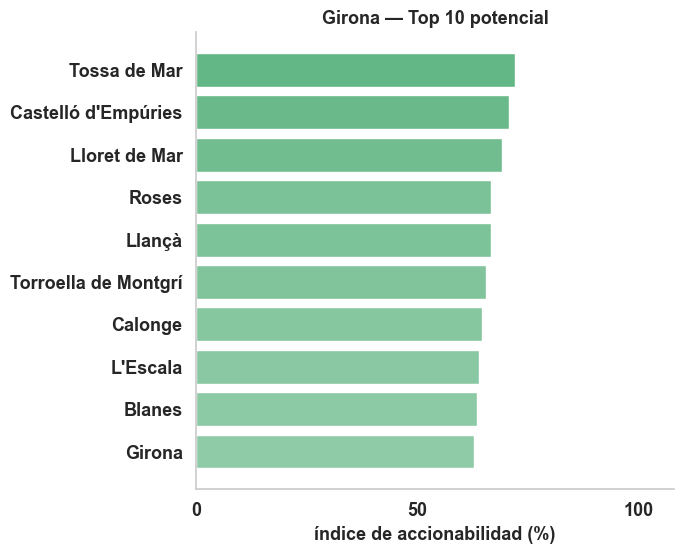

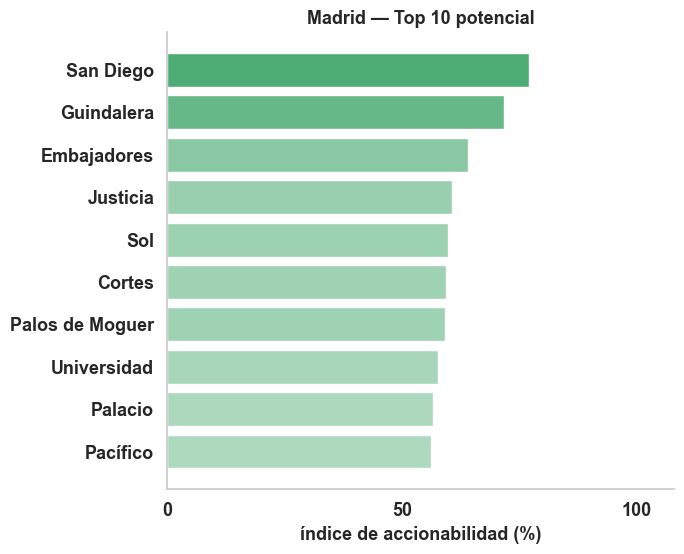

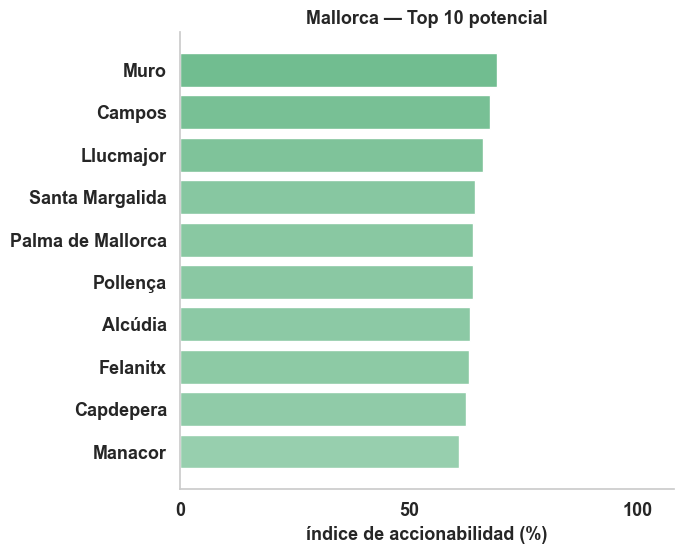

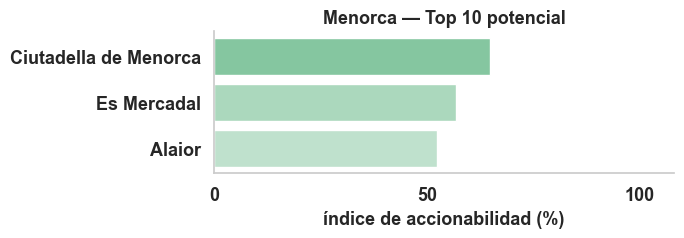

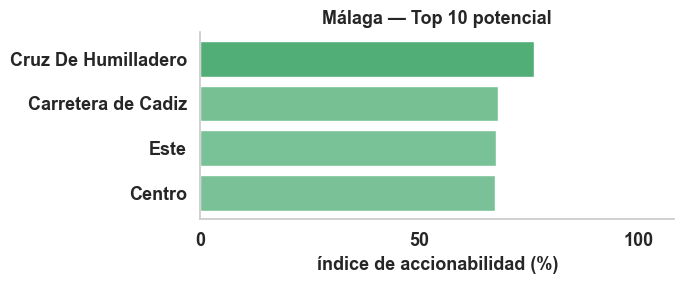

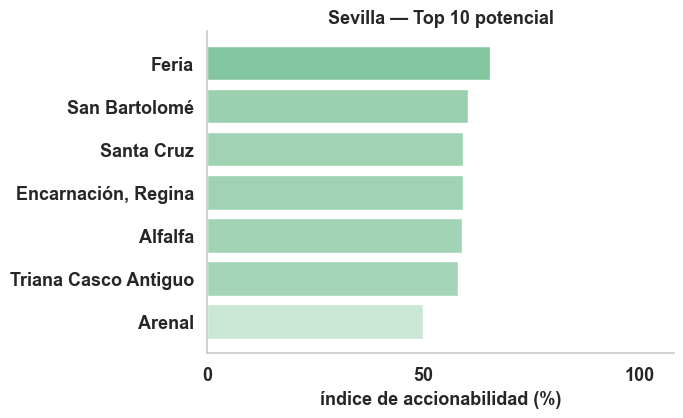

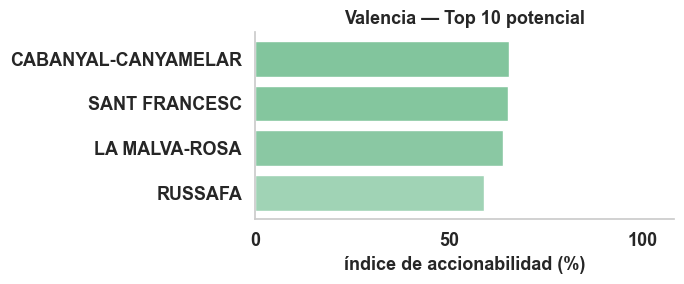

In [15]:
# Color de marca (placeholder: ajustar al logo real).
STAY_VERDE = "#2E9E5B"
STAY_BCN = "#32939b"  # color especial para el gráfico de Barcelona
norm = Normalize(foco["score_accion"].min(),
                 foco["score_accion"].max())

ALPHA_MIN, ALPHA_MAX = 0.25, 1.0  # menos ranking -> más transparente
FONTSIZE = 13
TOP_N = 10

# Nombres cortos para el Top 10 de Barcelona (solo para el gráfico).
BCN_RENAME = {
    "el Besòs i el Maresme": "Besòs - Maresme",
    "la Maternitat i Sant Ramon": "Maternitat - Sant Ramon",
    "el Putxet i el Farró": "Putxet - Farró",
    "el Parc i la Llacuna del Poblenou": "Parc i Llacuna",
    "la Nova Esquerra de l'Eixample": "Nova Esquerra",
    "Hostafrancs": "Hostafrancs",
    "Sant Gervasi - Galvany": "Sant Gervasi - Galvany",
    "el Raval": "Raval",
    "el Poblenou": "Poblenou",
    "el Camp de l'Arpa del Clot": "Camp de l'Arpa",
}

for city in sorted(foco["city"].unique()):
    d = (
        foco[foco["city"] == city]
        .sort_values("score_accion")
        .tail(TOP_N)
    )
    es_bcn = city == "Barcelona"
    color_base = STAY_BCN if es_bcn else STAY_VERDE
    etiquetas = (
        d["neighbourhood_name"].replace(BCN_RENAME)
        if es_bcn else d["neighbourhood_name"]
    )
    alphas = ALPHA_MIN + norm(d["score_accion"]) * (ALPHA_MAX - ALPHA_MIN)
    colors = [to_rgba(color_base, alpha=a) for a in alphas]
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(d) + 1.2))
    ax.barh(etiquetas, d["score_accion"], color=colors)
    ax.set_title("%s — Top 10 potencial" % city,
                 fontsize=FONTSIZE, fontweight="bold")
    ax.set_xlabel("índice de accionabilidad (%)",
                  fontsize=FONTSIZE, fontweight="bold")
    ax.set_xlim(0, 108)
    ax.set_xticks([0, 50, 100])
    ax.tick_params(axis="both", labelsize=FONTSIZE)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
    ax.grid(False)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    plt.tight_layout()
    plt.show()

**Alternativa de estética** para Barcelona: mismo Top 10, mismos colores
y mismos nombres cortos, pero en barras verticales con los nombres de
barrio en diagonal (en vez de horizontal en el eje Y), para comparar
qué disposición se lee mejor.

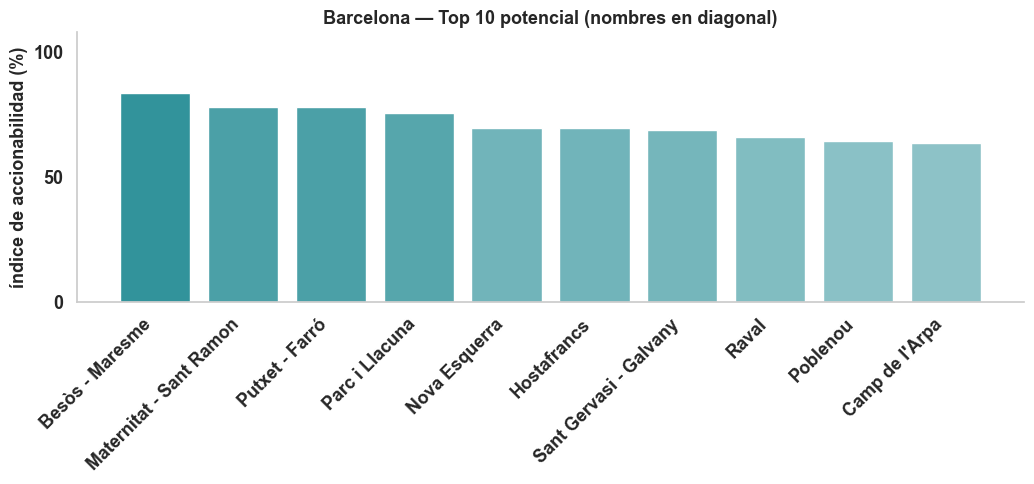

In [16]:
d_bcn = (
    foco[foco["city"] == "Barcelona"]
    .sort_values("score_accion", ascending=False)
    .head(TOP_N)
)
etiquetas_bcn = d_bcn["neighbourhood_name"].replace(BCN_RENAME)
alphas_bcn = ALPHA_MIN + norm(d_bcn["score_accion"]) * (ALPHA_MAX - ALPHA_MIN)
colors_bcn = [to_rgba(STAY_BCN, alpha=a) for a in alphas_bcn]

fig, ax = plt.subplots(figsize=(0.9 * len(d_bcn) + 1.5, 5))
ax.bar(etiquetas_bcn, d_bcn["score_accion"], color=colors_bcn)
ax.set_title("Barcelona — Top 10 potencial (nombres en diagonal)",
             fontsize=FONTSIZE, fontweight="bold")
ax.set_ylabel("índice de accionabilidad (%)",
              fontsize=FONTSIZE, fontweight="bold")
ax.set_ylim(0, 108)
ax.set_yticks([0, 50, 100])
ax.tick_params(axis="y", labelsize=FONTSIZE)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         fontsize=FONTSIZE, fontweight="bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")
ax.grid(False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

### 5.3. Barrios de mayor potencial (más acciones)

In [17]:
top = foco.sort_values(
    ["score_accion", "n"], ascending=[False, False]
)
top[["city", "neighbourhood_name", "n", "n_acciones",
     "score_accion", "acciones"]].head(10).round(1)

,city,neighbourhood_name,n,n_acciones,score_accion,acciones
29,Barcelona,el Besòs i el Maresme,26,4,83.7,ubicación floja: campaña de marketing de zona ...
54,Barcelona,la Maternitat i Sant Ramon,23,4,78.3,ubicación floja: campaña de marketing de zona ...
42,Barcelona,el Putxet i el Farró,24,4,78.1,ubicación floja: campaña de marketing de zona ...
276,Madrid,San Diego,23,4,77.2,ubicación floja: campaña de marketing de zona ...
358,Málaga,Cruz De Humilladero,24,4,76.0,ubicación floja: campaña de marketing de zona ...
39,Barcelona,el Parc i la Llacuna del Poblenou,36,4,75.7,ubicación floja: campaña de marketing de zona ...
169,Girona,Tossa de Mar,35,3,72.1,"calidad: subir rating hacia 4,8+ | noches mín:..."
231,Madrid,Guindalera,23,4,71.7,ubicación floja: campaña de marketing de zona ...
92,Girona,Castelló d'Empúries,48,3,70.8,"calidad: subir rating hacia 4,8+ | noches mín:..."
55,Barcelona,la Nova Esquerra de l'Eixample,96,4,69.8,ubicación floja: campaña de marketing de zona ...


### 5.4. Hallazgos a nivel barrio

In [18]:
print("barrios evaluados:", len(barrio))
print("con ubicación floja (<4,8):", int(barrio["a_ubicacion"].sum()))
print("rango de accionabilidad: %.0f a %.0f"
      % (foco["score_accion"].min(), foco["score_accion"].max()))

barrios evaluados: 82
con ubicación floja (<4,8): 14
rango de accionabilidad: 50 a 84


Al hacer zoom aparece:

- **La ubicación floja cambia quién lidera el ranking.** Ahora que suma
  como 4ª palanca, el top-10 de accionabilidad (tabla 5.3) ya no lo
  dominan los núcleos turísticos centrales, sino barrios **periféricos**
  que acumulan las 4 acciones a la vez: el Besòs i el Maresme, la
  Maternitat i Sant Ramon o el Putxet i el Farró en Barcelona; San
  Diego o Guindalera en Madrid; Cruz de Humilladero en Málaga — mala
  ubicación + rating bajo + noches fuera de rango, todo junto.
- **Conviven dos perfiles en el top:** el "periférico completo" (4
  acciones, arriba) y el "turístico consolidado" (Tossa de Mar,
  Castelló d'Empúries…) con buena ubicación pero rating y noches que
  aún fallan — 3 acciones en vez de 4, algo menos accionable en el
  índice pero con mucho más recorrido de marca ya construido.
- **A más tamaño de barrio, peor rating relativo:** el % de anuncios con
  rating bajo correlaciona **positivo (+0,27)** con el nº de anuncios
  del barrio — el problema de calidad no es solo de barrios pequeños,
  pesa más justo donde hay más volumen de anuncios que optimizar.
- **A menos tamaño, más ubicación floja:** el % de anuncios con
  ubicación floja correlaciona **negativo (-0,22)** con el nº de
  anuncios — los barrios con menos oferta tienden a ser también los
  peor ubicados, coherente con que son zonas menos turísticas.
- **14 de los 82 barrios (17%) tienen ubicación floja** (mediana <4,8):
  ya no se descartan del foco, se marcan con marketing de zona.
- `max_nights` suma parejo en casi todos los barrios (regularización
  transversal, poco discriminante); rating y noches mínimas siguen
  siendo las palancas más comunes (51 de 82 barrios con exactamente 3
  acciones).

## 6. Propuesta: piloto en las 2 ciudades de mayor volumen

Elegimos las 2 ciudades con más **anuncios accionables** (tabla 4.2):
donde el mismo esfuerzo llega a más alojamientos.

In [19]:
top2 = oportunidad.head(2).index.tolist()
print("Ciudades del piloto (por volumen):", top2)
piloto = (
    foco[foco["city"].isin(top2)]
    .sort_values(["city", "score_accion"],
                 ascending=[True, False])
    .groupby("city").head(3)
)
piloto[["city", "neighbourhood_name", "n",
        "score_accion", "acciones"]].round(1)

Ciudades del piloto (por volumen): ['Barcelona', 'Madrid']


,city,neighbourhood_name,n,score_accion,acciones
29,Barcelona,el Besòs i el Maresme,26,83.7,ubicación floja: campaña de marketing de zona ...
54,Barcelona,la Maternitat i Sant Ramon,23,78.3,ubicación floja: campaña de marketing de zona ...
42,Barcelona,el Putxet i el Farró,24,78.1,ubicación floja: campaña de marketing de zona ...
276,Madrid,San Diego,23,77.2,ubicación floja: campaña de marketing de zona ...
231,Madrid,Guindalera,23,71.7,ubicación floja: campaña de marketing de zona ...
224,Madrid,Embajadores,236,64.1,"calidad: subir rating hacia 4,8+ | noches mín:..."


### 6.1. Plan del piloto (borrador)

**Objetivo:** validar en las 2 ciudades de mayor volumen el efecto de las
acciones antes de escalar al resto.

**Alcance:** los 3 barrios más accionables de cada ciudad (tabla 6). En
esta edición los 6 barrios del piloto son mayoritariamente del perfil
**"periférico completo"** (ubicación floja + rating + noches, ver 5.4):
el Besòs i el Maresme, la Maternitat i Sant Ramon, el Putxet i el Farró
(Barcelona) y San Diego, Guindalera (Madrid); solo Embajadores
(Madrid) es del perfil "turístico consolidado" (3 acciones, ubicación
ya buena).

| Acción | KPI a seguir | Referencia esperada |
|---|---|---|
| Subir rating hacia 4,8+ | `review_scores_rating` | Superhost → *+22% reservas* |
| Ajustar noches mín a 3-4 | `minimum_nights` | óptimo de ingresos |
| Regularizar noches máx >31 | `maximum_nights` | cumplimiento legal |
| Marketing de zona en barrios con ubicación <4,8 | `review_scores_location` | mejora de percepción/atractivo de la zona |

**Medición:** comparar los KPI de los barrios piloto **antes vs después**
y contra barrios similares no intervenidos (grupo de control).

> **_A cuantificar con negocio:_** metas numéricas concretas y presupuesto;
> aquí fijamos el marco, el foco y el KPI, no la cifra exacta.

> **_Limitación a tener en cuenta:_** en Madrid el zoom por barrio solo
> cubre el 63% de sus anuncios (ver aviso en 4.2); antes de comprometer
> presupuesto conviene revisar si los barrios grandes excluidos por
> N<20 cambiarían la selección del piloto.

### 6.2. Conclusión

El potencial está en **calidad (rating < 4,8, generalizado en las 8
ciudades)**, en **acercar la estancia mínima a 3-4**, en **marketing de
zona para los barrios con ubicación floja** — que ahora lideran el
ranking de accionabilidad por acumular las 4 palancas a la vez — y en
una **regularización transversal** de `max_nights`. El volumen manda en
**Barcelona y Madrid**, que centran el piloto, aunque la cobertura
desigual del filtro N≥20 (4.2) pide leer esa selección con cautela,
sobre todo en Madrid, Sevilla y Valencia.